In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false; // disable scroll bar when displaying Folium map
}

<IPython.core.display.Javascript object>

# Assignment 2: Climate Data Visualization — Ann Arbor, MI

## Overview
This assignment uses historical weather station data from the **NCEI Global Historical Climatology Network (GHCN-Daily)** to create a data visualization showing record high and low temperatures near Ann Arbor, Michigan. It practices the full data science workflow: loading raw data, cleaning, grouping, and visualization.

## Research Question
**How do 2015 temperature extremes in Ann Arbor compare to the historical record (2005–2014)?** Did 2015 break any existing records?

## Learning Objectives
- Load and parse date strings from CSV data
- Filter, group, and aggregate time-series data with pandas
- Produce multi-layered matplotlib visualizations (line chart + fill_between + scatter)
- Follow Tufte's data-ink ratio principles: clean, labeled, informative charts

## Dataset
- **File**: `assets/assignment_data.csv` — Subset of NCEI GHCN-Daily data for Ann Arbor, MI
- **Columns**: `ID` (station), `Date` (YYYY-MM-DD), `Element` (TMAX/TMIN), `Data_Value` (tenths °C)
- **Note**: Values are in tenths of degrees Celsius. Divide by 10 to get °C.

## Steps
1. Load data, convert temperatures, extract day-of-year, drop Feb 29 (leap day)
2. Separate TMAX and TMIN records
3. Group by date: find daily max (TMAX) and daily min (TMIN) across all stations
4. Split into 2005–2014 baseline and 2015; compute per-day-of-year records from baseline
5. Identify 2015 points that exceed the 10-year record; plot everything

## Station Location Map
The cell below attempts to display the weather station location using Folium (an interactive mapping library). If Folium is not installed, the map won't render — the actual data analysis steps follow below.

In [2]:
#  I'll be using the folium package to render the data into a map in Jupyter.

import folium
import pandas as pd

# get the location information for this dataset
df = pd.read_csv('assets/BinSize_d400.csv')
station_locations_by_hash = df[df['hash'] == 'fb441e62df2d58994928907a91895ec62c2c42e6cd075c2700843b89']

# get longitude and lattitude to plot
lons = station_locations_by_hash['LONGITUDE'].tolist()
lats = station_locations_by_hash['LATITUDE'].tolist()

# plot on a beautiful folium map
my_map = folium.Map(location = [lats[0], lons[0]], height = 500,  zoom_start = 9)
for lat, lon in zip(lats, lons):
    folium.Marker([lat, lon]).add_to(my_map)

# render map in Jupyter
display(my_map)

### What This Code Does
- Reads the CSV and converts `Data_Value` from tenths of °C to °C
- Extracts the month-day portion of each date to handle leap year alignment
- Drops February 29 entries to keep all years at 365 days
- Splits into `df_max_temp` (TMAX rows) and `df_min_temp` (TMIN rows)

## Step 1
Load the dataset and transform the data into Celsius (refer to documentation) then extract all of the rows which have minimum or maximum temperatures.

__hint: when I did this step I had two DataFrame objects, each with ~80,000 entries in it__

In [3]:
import pandas as pd
df = pd.read_csv('assets/assignment_data.csv', delimiter=',' )
#df = pd.read_csv('assets/BinSize_d400.csv')              
df.head()
#df.shape

,ID,Date,Element,Data_Value
0,USW00094889,2014-11-12,TMAX,22
1,USC00208972,2009-04-29,TMIN,56
2,USC00200032,2008-05-26,TMAX,278
3,USC00205563,2005-11-11,TMAX,139
4,USC00200230,2014-02-27,TMAX,-106


### What This Code Does
- Uses `groupby('Date').max()` to find the daily maximum temperature across all stations
- Does the same for minimum temperatures
- Result: two DataFrames with one row per calendar date across all 11 years (4,015 rows each)

In [4]:
# In this code cell, transform the Data_Value column

df['Data_Value_Celcius'] = (df['Data_Value'] -32)*5/9
df.head(5)

df['Date'].dtype
df['Day_and_Month'] =df['Date'].apply(lambda x: x[5:])
df['Day_and_Month'].head()

i = df[ (df.Day_and_Month == '02-29')].index
print(i)
df.drop(i, inplace =True)
print("shape after dropping Feb 29", df.shape)

df_max_temp =df[df['Element'] =='TMAX']
df_min_temp =df[df['Element'] =='TMIN']

df_max_temp.shape
# df_min_temp.shape

Index([ 18712,  18716,  18729,  18730,  18812,  18817,  18942,  18962,  19014,
        19016,  19063,  19066,  19115,  19117,  19531,  19534,  19608,  19611,
        19680,  19696,  19907,  19910,  20216,  20223,  20331,  20364,  20397,
        20459,  20499,  20501,  20780,  20809,  21151,  21192,  23274,  23292,
        23551,  23553,  23661,  23662,  23666,  23676,  23736,  23745,  23782,
        23783, 123554, 123556, 123593, 123603, 123806, 123827, 125284, 125287,
       126164, 126166, 126241, 126247, 126345, 126365, 131157, 131159, 131533,
       131536, 131594, 131617, 131752, 132712, 132848, 133079, 133727, 133729,
       135278, 135281, 135437, 135592, 135779, 135781, 154086, 154089, 161046,
       161054, 164153],
      dtype='int64')
shape after dropping Feb 29 (165002, 6)


(83020, 6)

### What This Code Does
- Filters to extract the 365 rows for year 2015 from both max and min DataFrames
- Keeps the 3,650 rows for years 2005–2014
- Groups the 2005–2014 data by day-of-year (`Day_and_Month`) to find the historical record high and record low for each of the 365 days of the year

## Step 2
In order to visualize the data we would plot the min and max data for each day of the year between the years 2005 and 2014 across all weather stations. But we also need to find out when the min or max temperature in 2015 falls below the min or rises above the max for the previous decade.

If you did step 1 you have two Series objects with min and max times for the years 2005 through 2015. You can use Pandas `groupby` to create max and min temperature Series objects across all weather stations for each day of these years, and you can deal with the records for February 29 (the leap year) by dropping them.

__hint: when I finished this step, I had two DataFrame objects, each with exactly 4015 observations in them__

### What This Code Does
- Plots historical record highs (red line) and lows (blue line) for days 1–365
- Shades the region between them to show the historical temperature band
- Overlays scatter points (`x` markers) only for 2015 days that broke the record high or set a new record low
- Labels axes, adds legend, and sets month-name x-tick labels for readability

In [5]:
# create a DataFrame of maximum temperature by date
df_max_daily = df_max_temp.groupby(by ='Date').max()

df_min_daily = df_min_temp.groupby(by ='Date').max()

df_max_daily.head()
df_max_daily.drop(columns = ['ID', 'Element', 'Data_Value', ], axis=1, inplace =True)
df_min_daily.drop(columns = ['ID', 'Element', 'Data_Value' ], axis=1, inplace =True)
#df_min_daily.head()
print(df_max_daily.shape)
print(df_min_daily.shape)

# create a DataFrame of minimum temperatures by date

(4015, 2)
(4015, 2)


## Step 3
Now that you have grouped the daily max and min temperatures for each day of the years 2005 through 2015, you can separate out the data for 2015. Then you can use the Pandas `groupby` function to find the max and min of the temperature data for each __day of the year__ for the 2005-2014 data.

__hint: at the end of this step I had two DataFrames, one of maximum and the other of minimum values, which each had 365 observations in them. I also had another pair of similar DataFrames but only for the year 2015.__

In [6]:
# calculate the minimum and maximum values for the day of the year for 2005 through 2014

df_max_daily.head(5)
df_max_daily.index

df_max_2015 = df_max_daily[df_max_daily.index.map(lambda x: '2015' in x)]
#df_max_2015.head()
print(df_max_2015.shape)

df_min_2015 = df_min_daily[df_min_daily.index.map(lambda x: '2015' in x)]
print(df_min_2015.shape)

df_max_daily_2014 = df_max_daily[df_max_daily.index.map(lambda x: '2015' not in x)]
print(df_max_daily_2014.shape)

df_min_daily_2014 = df_min_daily[df_min_daily.index.map(lambda x: '2015' not in x)]
print(df_min_daily_2014.shape)

df_max_daily_2014_per_day =df_max_daily_2014.groupby(by ="Day_and_Month").max()
print(df_max_daily_2014_per_day.shape)
df_min_daily_2014_per_day = df_min_daily_2014.groupby(by ="Day_and_Month").min()
print(df_min_daily_2014_per_day.shape)



(365, 2)
(365, 2)
(3650, 2)
(3650, 2)
(365, 1)
(365, 1)


## Step 4
Now it's time to plot! You need to explore matplotlib in order to plot line graphs of the min and max temperatures for the years 2005 through 2014 and to scatter plot __only__ the daily 2015 temperatures that exceeded those values.

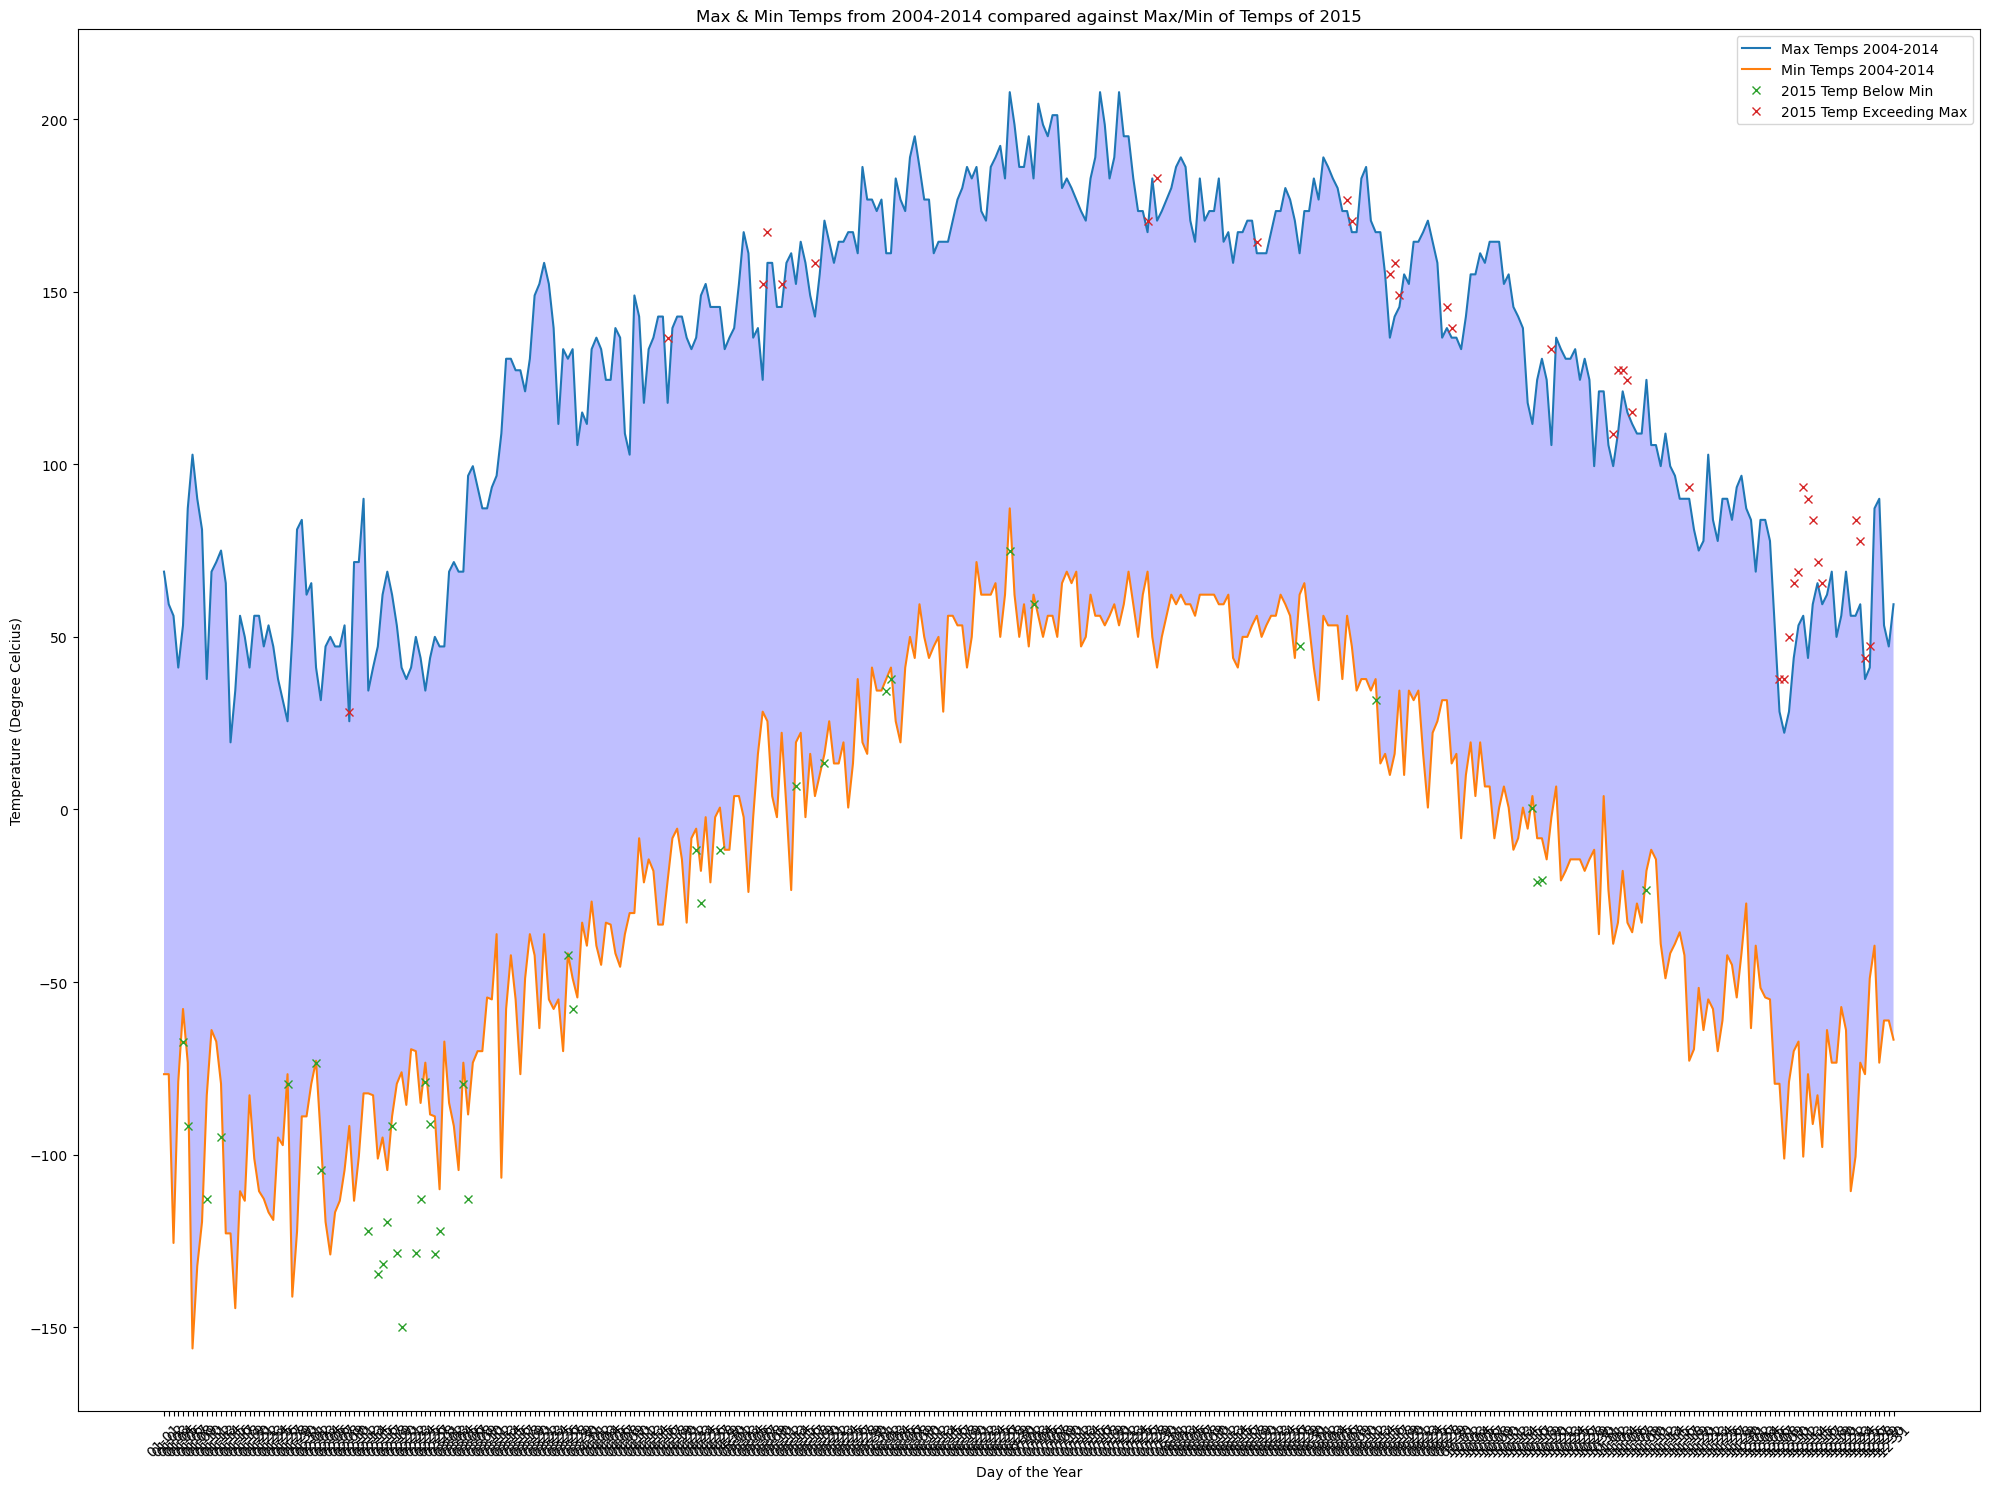

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
from calendar import month_abbr
import numpy as np
# put your plotting code here!

plt.figure(figsize = (20,15))
y_values_min = np.array(df_min_daily_2014_per_day['Data_Value_Celcius'])
x_values_min = np.array(df_min_daily_2014_per_day.index)

y_values_max = np.array(df_max_daily_2014_per_day['Data_Value_Celcius'])
x_values_max = np.array(df_max_daily_2014_per_day.index)

line1 = plt.plot(x_values_max, y_values_max, '-',  label = "Max Temps 2004-2014" )
line2 = plt.plot(x_values_min, y_values_min, '-', label= "Min Temps 2004-2014" )
axes = plt.gca()
axes.legend()

# Rotate x-axis tick labels for readability
x = plt.gca().xaxis
for item in x.get_ticklabels():
    item.set_rotation(45)

plt.gca().fill_between(range(len(y_values_min)), 
                       y_values_min, y_values_max, 
                       facecolor='blue', 
                       alpha=0.25)

df_max_2015.reset_index(inplace = True)
df_max_daily_2014_per_day.reset_index(inplace = True)

df_min_2015.reset_index(inplace = True)
df_min_daily_2014_per_day.reset_index(inplace = True)

df_max_2015_overlay = df_max_2015.where(df_max_2015['Data_Value_Celcius'] > df_max_daily_2014_per_day['Data_Value_Celcius'],np.nan)
df_min_2015_overlay = df_min_2015.where(df_min_2015['Data_Value_Celcius'] < df_min_daily_2014_per_day['Data_Value_Celcius'],np.nan)

array_max_2015_overlay = np.array(df_max_2015_overlay['Data_Value_Celcius'])
array_min_2015_overlay = np.array(df_min_2015_overlay['Data_Value_Celcius'])

line3 = plt.plot(x_values_min, array_min_2015_overlay, 'x', label ="2015 Temp Below Min",)
line4 = plt.plot(x_values_max, array_max_2015_overlay, 'x', label = "2015 Temp Exceeding Max",)
axes = plt.gca()
axes.legend()

plt.title("Max & Min Temps from 2004-2014 compared against Max/Min of Temps of 2015")
plt.ylabel("Temperature (Degree Celcius)")
plt.xlabel("Day of the Year")

plt.tight_layout()
plt.savefig('temperature_comparison.png', dpi=100)
plt.show()